# Radiator Design Code — CB8

Parameterized heat-rejection model with speed-derived + fan air velocity.
Edit the **Config** cell and re-run — no file save needed.

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings


## Config — edit here, then re-run this cell and the cells below

- **Temperatures**: air °C, coolant °F
- **Geometry**: mm
- **Expected heat**: inline dict `{RPM: heat_W}` — update with new Realis data as it comes in
- **Shift points**: RPM + mph at each ideal upshift
- **Fan**: `FAN_SPEED_MS` = fan-only face velocity; `FAN_ON` to toggle

In [66]:
# ---- TEMPERATURES -----------------------------------------------------------
T_AIR_C = 38              # Inlet air temp, C
T_WATER_F = 240       # Inlet coolant temp, F

# ---- GEOMETRY (radiator core dimensions, mm) --------------------------------
GEOMETRY_MM = {
    'r_L': 235,         # Radiator core length, tank to tank, mm
    'r_H': 188,         # Radiator core height, mm
    'r_t': 25,          # Radiator core thickness, mm
    't_H': 1.94,        # Coolant tube thickness, outside to outside, mm
    't_t': 0.3302,      # Coolant tube wall thickness, mm (estimated)
    'f_H': 6.83,        # Fin height (spacing between flow tubes), mm
    'f_D': 1.3208,      # Fin spacing, center to center, mm
    'f_t': 0.1200,      # Fin thickness, mm
}
K_AL = 154              # Thermal conductivity of aluminum, W/m-K

# Set True for a dual-pass radiator (coolant U-turns through two series passes).
# In dual-pass: N_tubes/2 per pass, per-tube coolant velocity doubles,
# each pass gets half the air-side channels at the same inlet air temp.
DUAL_PASS = True

# ---- REV RANGE — RPM points to evaluate -------------------------------------
RPM_MIN = 1500
RPM_MAX = 11000
RPM_STEP = 500
RPM_RANGE = np.arange(RPM_MIN, RPM_MAX + RPM_STEP, RPM_STEP)

# ---- Less commonly changed --------------------------------------------------
P_I_AIR = 101000       # Inlet air pressure, Pa
C_P_AIR = 1007         # J/kg-K
C_P_WATER = 4181.3     # J/kg-K

# ---- EXPECTED HEAT ----------------------------------------------------------
# Expected heat load vs RPM from Realis (or other simulation).
# Format: {RPM: heat_W}. Add, remove, or update rows as new sim data comes in.
EXPECTED_HEAT = {
      2000.00:   1859.12,
      2317.24:   1972.50,
      2634.49:   2302.72,
      2951.72:   2349.13,
      3268.96:   2424.18,
      3586.20:   2483.25,
      3903.45:   2888.19,
      4220.70:   3346.74,
      4537.93:   3643.32,
      4855.17:   3942.27,
      5172.41:   4176.29,
      5489.66:   4309.87,
      5806.90:   4534.50,
      6124.14:   4840.15,
      6441.39:   4957.86,
      6758.63:   5004.73,
      7075.86:   5154.68,
      7393.10:   5429.05,
      7710.35:   5686.31,
      8027.59:   5965.69,
      8344.82:   6197.83,
      8662.07:   6363.21,
      8979.31:   6609.34,
      9296.55:   6798.39,
      9613.79:   6998.20,
      9931.04:   7202.31,
     10248.27:   7356.58,
     10565.52:   7448.03,
     10882.76:   7458.12,
}

# ---- SHIFT POINTS -----------------------------------------------------------
# RPM and vehicle speed at each ideal upshift. Air velocity at every point is
# derived from vehicle speed, so each case is at its real aero condition.
SHIFT_POINTS = {
    '1st gear': {'rpm': 10909, 'mph': 31.60},
    '2nd gear': {'rpm': 10789, 'mph': 41.85},
    '3rd gear': {'rpm': 10589, 'mph': 53.48},
    '4th gear': {'rpm': 10229, 'mph': 64.86},
    '5th gear': {'rpm':  9833, 'mph': 74.29},
    'Max RPM':  {'rpm': 11000, 'mph': 74.29},
}

# RPM at which 1st gear begins (approximate launch / clutch-dump RPM)
LAUNCH_RPM = 4000

# Fraction of free-stream vehicle speed that reaches the radiator core face.
AIR_RESTRICTION = 1

# ---- FAN --------------------------------------------------------------------
# Mishimoto slim 8" electric fan — face velocity through the core at rest.
# Combined with ram air via quadrature (pressures add, not velocities):
#   u_eff = sqrt(u_ram² + u_fan²)
# Set FAN_SPEED_MS = 0 or FAN_ON = False to model ram air only.
FAN_SPEED_MS = 5    # m/s through the core face from the fan alone (v_vehicle = 0)
FAN_ON = True         # set False to compare without fan

# Marker colors for each shift point (must match length of SHIFT_POINTS)
SHIFT_POINT_COLORS = ['tab:blue', 'tab:cyan', 'tab:green', 'gold', 'tab:orange', 'red']


In [67]:
def build_geometry():
    """Converts GEOMETRY_MM (mm) to the meters dict solve_radiator expects."""
    geom = {k: v * 1e-3 for k, v in GEOMETRY_MM.items()}
    geom['k_al'] = K_AL
    return geom


def build_conditions():
    """Assembles base thermal/pressure conditions from the Config block.
    Air velocity is NOT set here — it is always derived from vehicle speed
    via combined_air_velocity() at each operating point.
    """
    return {
        'P_i_air': P_I_AIR,
        'T_mi_air': T_AIR_C + 273.15,
        'T_mi_water': (T_WATER_F - 32) / 1.8 + 273.15,
        'c_p_air': C_P_AIR,
        'c_p_water': C_P_WATER,
    }


## Physics & solver — no edits needed

In [68]:
def get_mu_air(T):
    """Dynamic viscosity of air, Pa-s. T in K."""
    return 2.791e-7 * T**0.7355


def get_rho_air(P, T):
    """Density of air, kg/m^3. P in Pa, T in K."""
    return P / (287.053 * T)


def get_Pr_air(T):
    """Prandtl number of air. T in K."""
    T = T - 273.15
    return 1e9 / (1.1*T**3 - 1200*T**2 + 322000*T + 1.393e9)


def get_mu_water(T):
    """Dynamic viscosity of water, Pa-s. T in K."""
    return 0.02939e-3 * np.exp(507.88 / (T - 149.3))


def get_rho_water(T):
    """Density of water, kg/m^3. T in K."""
    T = T - 273.15
    t1 = 999.83952 + 16.945176*T
    t2 = -7.9870401e-3*T**2
    t3 = -46.170461e-6*T**3
    t4 = 105.56302e-9*T**4
    t5 = -280.54253e-12*T**5
    return (t1+t2+t3+t4+t5) / (1+16.897850e-3*T)


def get_Pr_water(T):
    """Prandtl number of water. T in K."""
    T = T - 273.15
    return 50000 / (T**2 + 155*T + 3700)


def get_k(c_p, mu, Pr):
    """Thermal conductivity of a fluid, W/m-K, from c_p, mu, Pr."""
    return c_p * mu / Pr


# ---------------------------------------------------------------------------
# Geometry (all explicit — no hidden globals)
# ---------------------------------------------------------------------------

def get_N_fins(r_L, f_D, f_t):
    """Number of fins along the length of the radiator."""
    return round(r_L / (f_D - f_t), 0)


def get_N_tubes(r_H, f_H, t_H):
    """Number of coolant tubes across the height of the radiator."""
    return round((r_H - f_H) / (f_H + t_H), 0)


def get_Ac_air(f_D, f_H, f_t):
    """Cross sectional area of an air passage between fins, m^2."""
    return (f_D - 2*f_t) * (f_H - f_t)


def get_P_air(f_D, f_H, f_t):
    """Wetted perimeter of an air passage between fins, m."""
    return 2*(f_D - 2*f_t) + 2*(f_H - f_t)


def get_Dh_air(f_D, f_H, f_t):
    """Hydraulic diameter of the air passages, m."""
    A_c = get_Ac_air(f_D, f_H, f_t)
    P = get_P_air(f_D, f_H, f_t)
    return 4*A_c / P


def get_Ac_tube(r_t, t_H, t_t):
    """Cross sectional area of the coolant tube, m^2."""
    return (r_t - 2*t_t) * (t_H - 2*t_t)


def get_P_tube(r_t, t_H, t_t):
    """Wetted perimeter of the coolant tube, m."""
    return 2*(r_t - 2*t_t) + 2*(t_H - 2*t_t)


def get_Dh_water(r_t, t_H, t_t):
    """Hydraulic diameter of the coolant tube, m."""
    A_c = get_Ac_tube(r_t, t_H, t_t)
    P = get_P_tube(r_t, t_H, t_t)
    return 4*A_c / P


def get_Atot_air(P, L, N_fins, N_tubes):
    """Total air-side heat transfer area, m^2."""
    return P * L * N_fins * (N_tubes + 1)


def get_Atot_water(P, L, N_tubes):
    """Total coolant-side heat transfer area, m^2."""
    return P * L * N_tubes


def get_Atot_al(r_t, r_L, N_tubes):
    """Total aluminum conduction area, m^2."""
    return r_t * r_L * (2*N_tubes)


# ---------------------------------------------------------------------------
# Flow / heat transfer
# ---------------------------------------------------------------------------

def get_mdot(rho, u_m, A_c):
    """Mass flow rate, kg/s."""
    return rho * u_m * A_c


def get_um_from_vdot(A_c, vdot):
    """Fluid velocity from volumetric flow rate, m/s."""
    return vdot / A_c


def get_um_from_mdot(A_c, rho, mdot):
    """Fluid velocity from mass flow rate, m/s."""
    return mdot / (rho * A_c)


def get_Reynolds(rho, u_m, D, mu):
    return rho * u_m * D / mu


def get_Gz(D, x, Re, Pr):
    """Graetz number."""
    return D * Re * Pr / x


def get_friction_factor(Re):
    return (0.790*np.log(Re) - 1.64)**(-2)


def get_Nusselt_laminar(Gz, Pr):
    """Nusselt number, developing laminar flow."""
    a = 3.66 / np.tanh(2.264*Gz**(-1/3) + 1.7*Gz**(-2/3))
    b = 0.0499 * Gz * np.tanh(Gz**(-1))
    d = np.tanh(2.432*Pr**(1/6) * Gz**(-1/6))
    return (a+b) / d


def get_Nusselt_turbulent(Re, Pr, f, D, x):
    """Nusselt number, developing turbulent flow."""
    Nu = ((f/8)*(Re-1000)*Pr) / (1 + 12.7*(f/8)**0.5*(Pr**(2/3)-1))
    return Nu * (1 + 2.4254/((x/D)**0.760))


def get_barh(Nu, k, D):
    """Average heat transfer coefficient, W/m^2-K."""
    return Nu * k / D


RE_TRANSITION_AIR = 2377.2     # laminar/turbulent crossover used for air passages
RE_TRANSITION_WATER = 1500     # laminar/turbulent crossover used for coolant tubes


def get_h_air(mdot, T_mi, c_p, f_D, f_H, f_t, r_t):
    """Average air-side heat transfer coefficient. f_t is a real argument here."""
    A_c = get_Ac_air(f_D, f_H, f_t)
    D = get_Dh_air(f_D, f_H, f_t)
    mu = get_mu_air(T_mi)
    rho_um = mdot / A_c
    Re = np.array(get_Reynolds(rho_um, 1, D, mu), ndmin=1)
    sel_lam = Re < RE_TRANSITION_AIR
    sel_tur = ~sel_lam
    Pr = get_Pr_air(T_mi)
    k = get_k(c_p, mu, Pr)
    Gz = get_Gz(D, r_t, Re, Pr)
    f = get_friction_factor(Re)
    Nu = np.zeros(len(Re))
    Nu[sel_lam] = get_Nusselt_laminar(Gz[sel_lam], Pr)
    Nu[sel_tur] = get_Nusselt_turbulent(Re[sel_tur], Pr, f[sel_tur], D, r_t)
    h = get_barh(Nu, k, D)
    return (h[0], Re[0]) if len(Re) == 1 else (h, Re)


def get_h_water(mdot, T_mi, c_p, r_L, r_H, r_t, t_H, t_t):
    """Average coolant-side heat transfer coefficient. t_t is a real argument here."""
    A_c = get_Ac_tube(r_t, t_H, t_t)
    D = get_Dh_water(r_t, t_H, t_t)
    mu = get_mu_water(T_mi)
    rho = get_rho_water(T_mi)
    u_m = get_um_from_mdot(A_c, rho, mdot)
    Re = np.array(get_Reynolds(rho, u_m, D, mu), ndmin=1)
    sel_lam = Re < RE_TRANSITION_WATER
    sel_tur = ~sel_lam
    Pr = get_Pr_water(T_mi)
    k = get_k(c_p, mu, Pr)
    Gz = get_Gz(D, r_L, Re, Pr)
    f = get_friction_factor(Re)
    Nu = np.zeros(len(Re))
    Nu[sel_lam] = get_Nusselt_laminar(Gz[sel_lam], Pr)
    Nu[sel_tur] = get_Nusselt_turbulent(Re[sel_tur], Pr, f[sel_tur], D, r_L)
    h = get_barh(Nu, k, D)
    return (h[0], Re[0]) if len(Re) == 1 else (h, Re)


def get_hbar_al(k, t_t, f_t, f_D, r_t, f_H):
    """Average aluminum conduction heat transfer coefficient."""
    h_tube = k / (t_t + 0.5*f_t)
    A_tube = (f_D - f_t) * r_t
    h_fin = k * np.log(0.5*f_H/f_t) / (0.5*f_H - f_t)
    A_fin = 0.5 * (f_H - f_t) * r_t
    return (h_tube*A_tube + h_fin*A_fin) / (A_tube + A_fin)


def get_R_air(mdot, c_p, h, f_D, f_H, f_t, r_L, r_H, r_t, t_H):
    """Thermal resistance, air convection."""
    P = get_P_air(f_D, f_H, f_t)
    N_fins = get_N_fins(r_L, f_D, f_t)
    N_tubes = get_N_tubes(r_H, f_H, t_H)
    A = get_Atot_air(P, r_t, N_fins, N_tubes)
    return 1 / (mdot*c_p*(1 - np.exp(-A*h/(mdot*c_p))))


def get_R_water(h, f_H, r_L, r_H, r_t, t_H, t_t):
    """Thermal resistance, coolant convection."""
    P = get_P_tube(r_t, t_H, t_t)
    N_tubes = get_N_tubes(r_H, f_H, t_H)
    A = get_Atot_water(P, r_L, N_tubes)
    return 1 / (h*A)


def get_R_al(h, f_H, r_L, r_H, r_t, t_H):
    """Thermal resistance, aluminum conduction."""
    N_tubes = get_N_tubes(r_H, f_H, t_H)
    A = get_Atot_al(r_t, r_L, N_tubes)
    return 1 / (h*A)


def get_T_water_out(T_mia, T_miw, P, mdot, c_p, R_w, R, h, x):
    """Coolant outlet temperature, K."""
    return (T_miw - T_mia) * np.exp(-P*R_w*h*x/(mdot*c_p*R)) + T_mia


def get_q_rad(mdot, c_p, T_mi, T_mo):
    """Total heat rejected from the coolant, W."""
    return mdot * c_p * (T_mi - T_mo)


_rpm_range_warned = False  # shown at most once per kernel session


def get_vdot_from_rpm(rpm, rpm_points=None, vdot_lpm_points=None):
    """
    Convert engine RPM to total coolant volumetric flow rate (m^3/s) using
    piecewise-linear interpolation through measured CB5 coolant-flow-vs-RPM
    data points.

    Default anchor points from "4_COOO_1.DOC":
        1500 RPM -> 5 L/min, 3000 RPM -> 11 L/min, 9000 RPM -> 22 L/min
    Replace with CB8 measured data once available.
    """
    global _rpm_range_warned
    if rpm_points is None:
        rpm_points = np.array([1500, 3000, 9000])
    if vdot_lpm_points is None:
        vdot_lpm_points = np.array([5, 11, 22])

    rpm_arr = np.atleast_1d(np.asarray(rpm, dtype=float))

    if (not _rpm_range_warned and
            (np.any(rpm_arr < rpm_points.min()) or np.any(rpm_arr > rpm_points.max()))):
        print(f"Note: RPM outside calibrated range "
              f"({rpm_points.min():.0f}–{rpm_points.max():.0f} RPM); "
              "extrapolating linearly. Update rpm_points/vdot_lpm_points with CB8 flow data.")
        _rpm_range_warned = True

    vdot_lpm = np.interp(rpm_arr, rpm_points, vdot_lpm_points)
    below = rpm_arr < rpm_points[0]
    above = rpm_arr > rpm_points[-1]
    if np.any(below):
        slope = (vdot_lpm_points[1]-vdot_lpm_points[0]) / (rpm_points[1]-rpm_points[0])
        vdot_lpm[below] = vdot_lpm_points[0] + slope*(rpm_arr[below]-rpm_points[0])
    if np.any(above):
        slope = (vdot_lpm_points[-1]-vdot_lpm_points[-2]) / (rpm_points[-1]-rpm_points[-2])
        vdot_lpm[above] = vdot_lpm_points[-1] + slope*(rpm_arr[above]-rpm_points[-1])

    vdot_lpm = np.maximum(vdot_lpm, 0)
    vdot_m3s = vdot_lpm * 1e-3 / 60
    return vdot_m3s[0] if np.isscalar(rpm) else vdot_m3s
def get_deltap(f, rho, u_m, D, r_t):
    """Pressure drop across the radiator (fully-developed region only — see
    notebook Text Cell 15: real ΔP could be 2-4x this, entry-region loss is
    not modeled). Pa."""
    return f * rho * u_m**2 * r_t / (2*D)


# ---------------------------------------------------------------------------
# Top-level solver — the only function you need for normal use
# ---------------------------------------------------------------------------


def _solve_one_pass(g_pass, c, vdot_scalar, N_per, mdot_air_pass, h_air, h_al):
    """
    Solve heat rejection for one cross-flow pass of a dual-pass radiator.

    g_pass    : geometry dict with r_H already set to r_H_per_pass (so
                get_N_tubes returns N_per for this pass)
    c         : conditions dict with T_mi_water = inlet temp for THIS pass
    vdot_scalar: total coolant volumetric flow rate, m^3/s (all goes through
                 N_per tubes, so per-tube flow is vdot/N_per)
    N_per     : number of tubes in this pass
    mdot_air_pass: air mass flow associated with this pass (half total)
    h_air, h_al: pre-computed coefficients (don't depend on N_tubes)

    Returns (T_out, q, Re_water).
    """
    A_c_water = get_Ac_tube(g_pass['r_t'], g_pass['t_H'], g_pass['t_t'])
    rho_water = get_rho_water(c['T_mi_water'])
    u_m_water = get_um_from_vdot(A_c_water, vdot_scalar / N_per)
    mdot_water = get_mdot(rho_water, u_m_water, A_c_water) * N_per

    h_water, Re_water = get_h_water(
        mdot_water / N_per, c['T_mi_water'], c['c_p_water'],
        g_pass['r_L'], g_pass['r_H'], g_pass['r_t'], g_pass['t_H'], g_pass['t_t']
    )

    R_air   = get_R_air(mdot_air_pass, c['c_p_air'], h_air,
                         g_pass['f_D'], g_pass['f_H'], g_pass['f_t'],
                         g_pass['r_L'], g_pass['r_H'], g_pass['r_t'], g_pass['t_H'])
    R_al    = get_R_al(h_al, g_pass['f_H'], g_pass['r_L'],
                        g_pass['r_H'], g_pass['r_t'], g_pass['t_H'])
    R_water = get_R_water(h_water, g_pass['f_H'], g_pass['r_L'],
                           g_pass['r_H'], g_pass['r_t'], g_pass['t_H'], g_pass['t_t'])
    R = R_air + R_al + R_water

    P_water = get_P_tube(g_pass['r_t'], g_pass['t_H'], g_pass['t_t'])
    T_out = get_T_water_out(
        c['T_mi_air'], c['T_mi_water'], P_water,
        mdot_water / N_per, c['c_p_water'], R_water, R, h_water, g_pass['r_L']
    )
    q = get_q_rad(mdot_water, c['c_p_water'], c['T_mi_water'], T_out)
    return T_out, q, Re_water


def solve_radiator(geometry, conditions, vdot, dual_pass=False):
    """
    Solve for total radiator heat rejection rate and coolant outlet temp.

    geometry : dict with keys
        r_L, r_H, r_t   - core length, height, thickness (m)
        t_H, t_t        - coolant tube thickness, wall thickness (m)
        f_H, f_D, f_t   - fin height, spacing, thickness (m)
        k_al            - thermal conductivity of aluminum (W/m-K)
    conditions : dict with keys
        P_i_air, T_mi_air, u_m_air   - inlet air pressure (Pa), temp (K), velocity (m/s)
        T_mi_water                   - inlet coolant temp (K)
        c_p_air, c_p_water           - specific heats (J/kg-K)
    vdot : float or array-like
        Total coolant volumetric flow rate(s), m^3/s
    dual_pass : bool
        If True, model a dual-pass radiator. The core is treated as two
        series cross-flow passes:
          - Each pass has N_tubes//2 tubes and the same tube length r_L.
          - Per-tube coolant velocity doubles (same total flow, half the tubes).
          - Each pass gets half the total air mass flow (the upper and lower
            halves of the core see independent air streams, both at T_ai).
          - Coolant outlet of pass 1 becomes the inlet of pass 2.
        This increases h_water (higher Re) and raises total heat rejection
        vs. the equivalent single-pass model.

    Returns: dict with q (W), T_mo_water (K), Re_air, Re_water, N_fins, N_tubes.
    """
    g, c = geometry, conditions
    scalar_input = np.isscalar(vdot)
    vdot = np.atleast_1d(np.asarray(vdot, dtype=float))

    N_fins  = get_N_fins(g['r_L'], g['f_D'], g['f_t'])
    N_tubes = get_N_tubes(g['r_H'], g['f_H'], g['t_H'])

    A_c_air = get_Ac_air(g['f_D'], g['f_H'], g['f_t'])
    rho_air = get_rho_air(c['P_i_air'], c['T_mi_air'])
    u_m_air = c['u_m_air']
    mdot_air_per_passage = get_mdot(rho_air, u_m_air, A_c_air)

    # Coefficients that don't depend on N_tubes
    h_air, Re_air = get_h_air(mdot_air_per_passage, c['T_mi_air'], c['c_p_air'],
                               g['f_D'], g['f_H'], g['f_t'], g['r_t'])
    h_al = get_hbar_al(g['k_al'], g['t_t'], g['f_t'], g['f_D'], g['r_t'], g['f_H'])

    if dual_pass:
        # Build a per-pass geometry: r_H sized so get_N_tubes returns N_per exactly
        N_per = N_tubes // 2
        r_H_per = N_per * (g['f_H'] + g['t_H']) + g['f_H']
        g_pass = dict(g, r_H=r_H_per)

        # Each pass gets half the air channels (proportional split)
        n_ch_total = N_tubes + 1
        n_ch_per   = N_per + 1
        mdot_air_pass = mdot_air_per_passage * N_fins * n_ch_per
    else:
        N_per = N_tubes
        g_pass = g
        mdot_air_pass = mdot_air_per_passage * N_fins * (N_tubes + 1)
        R_air = get_R_air(mdot_air_pass, c['c_p_air'], h_air,
                           g['f_D'], g['f_H'], g['f_t'],
                           g['r_L'], g['r_H'], g['r_t'], g['t_H'])
        R_al  = get_R_al(h_al, g['f_H'], g['r_L'], g['r_H'], g['r_t'], g['t_H'])

    q_out      = np.zeros_like(vdot)
    T_mo_out   = np.zeros_like(vdot)
    Re_water_out = np.zeros_like(vdot)

    for i, v in enumerate(vdot):
        if dual_pass:
            # Pass 1: hot coolant side
            T_mid, q1, Re_w1 = _solve_one_pass(
                g_pass, c, v, N_per, mdot_air_pass, h_air, h_al
            )
            # Pass 2: cooler coolant side, same inlet air temp
            c_pass2 = dict(c, T_mi_water=T_mid)
            T_wo, q2, Re_w2 = _solve_one_pass(
                g_pass, c_pass2, v, N_per, mdot_air_pass, h_air, h_al
            )
            q_out[i]       = q1 + q2
            T_mo_out[i]    = T_wo
            Re_water_out[i] = (Re_w1 + Re_w2) / 2  # mean across both passes

        else:
            A_c_water = get_Ac_tube(g['r_t'], g['t_H'], g['t_t'])
            u_m_water = get_um_from_vdot(A_c_water, v / N_tubes)
            rho_water = get_rho_water(c['T_mi_water'])
            mdot_water = get_mdot(rho_water, u_m_water, A_c_water) * N_tubes

            h_water, Re_water = get_h_water(
                mdot_water / N_tubes, c['T_mi_water'], c['c_p_water'],
                g['r_L'], g['r_H'], g['r_t'], g['t_H'], g['t_t']
            )
            R_water = get_R_water(h_water, g['f_H'], g['r_L'],
                                   g['r_H'], g['r_t'], g['t_H'], g['t_t'])
            R = R_air + R_al + R_water

            P_water = get_P_tube(g['r_t'], g['t_H'], g['t_t'])
            T_mo_water = get_T_water_out(
                c['T_mi_air'], c['T_mi_water'], P_water,
                mdot_water / N_tubes, c['c_p_water'], R_water, R, h_water, g['r_L']
            )
            q_out[i]       = get_q_rad(mdot_water, c['c_p_water'], c['T_mi_water'], T_mo_water)
            T_mo_out[i]    = T_mo_water
            Re_water_out[i] = Re_water

    result = {
        'q':          q_out[0]       if scalar_input else q_out,
        'T_mo_water': T_mo_out[0]    if scalar_input else T_mo_out,
        'Re_air':     Re_air,
        'Re_water':   Re_water_out[0] if scalar_input else Re_water_out,
        'N_fins':     N_fins,
        'N_tubes':    N_tubes,
    }
    return result


## Comparison & plotting functions — no edits needed

In [69]:

# ---------------------------------------------------------------------------
# Compare against an expected-heat-load CSV (e.g. exported from Realis)
# ---------------------------------------------------------------------------

def plot_expected_vs_modeled(comparison_df, title='Expected vs. Modeled Heat Rejection'):
    """Plot expected (e.g. Realis) heat load and modeled radiator heat
    rejection vs RPM on the same axes, to visually demonstrate cooling
    effectiveness / margin."""
    fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
    ax.plot(comparison_df['RPM'], comparison_df['Expected_Heat_W'], 'o-',
            color='tab:orange', label='Expected heat load (Realis)', linewidth=2)
    ax.plot(comparison_df['RPM'], comparison_df['Modeled_Heat_W'], 's-',
            color='tab:blue', label='Modeled radiator heat rejection', linewidth=2)
    ax.fill_between(comparison_df['RPM'], comparison_df['Expected_Heat_W'],
                     comparison_df['Modeled_Heat_W'],
                     where=comparison_df['Modeled_Heat_W'] >= comparison_df['Expected_Heat_W'],
                     color='tab:green', alpha=0.15, label='Margin (cooling > load)')
    ax.fill_between(comparison_df['RPM'], comparison_df['Expected_Heat_W'],
                     comparison_df['Modeled_Heat_W'],
                     where=comparison_df['Modeled_Heat_W'] < comparison_df['Expected_Heat_W'],
                     color='tab:red', alpha=0.2, label='Shortfall (cooling < load)')
    ax.set_xlabel('Engine RPM')
    ax.set_ylabel('Heat (W)')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    return fig



def combined_air_velocity(mph, air_restriction, fan_speed_ms, fan_on=True):
    """
    Effective air velocity through the radiator core face (m/s).

    Ram air and fan contributions are combined in quadrature — pressures add,
    not velocities:

        u_eff = sqrt(u_ram² + u_fan²)

    Derivation: the core resistance is ΔP ∝ u², so:
        ΔP_ram + ΔP_fan = C·u_ram² + C·u_fan² = C·u_eff²
    → u_eff = sqrt(u_ram² + u_fan²)

    This correctly models the fan's diminishing contribution at high vehicle
    speeds, unlike linear addition which is overly optimistic at the top end.

    Practical effect vs linear addition:
      At 74 mph (5th gear):  linear → 23.5 m/s  |  quadrature → 17.9 m/s
      At 32 mph (1st gear):  linear → 14.1 m/s  |  quadrature →  9.9 m/s
    """
    u_ram = mph * 0.44704 * air_restriction
    u_fan = fan_speed_ms if fan_on else 0.0
    return float(np.sqrt(u_ram**2 + u_fan**2))


def eval_shift_points(shift_points, air_restriction, geometry, conditions):
    """
    Evaluate FOS at each shift point using the vehicle speed for that case
    to derive the air velocity through the core (vehicle_speed * air_restriction).

    shift_points : dict of {label: {'rpm': ..., 'mph': ...}}
    air_restriction : float, fraction of free-stream that reaches the core face
    geometry, conditions : as passed to solve_radiator (conditions['u_m_air']
                           is overridden per case by the speed-derived velocity)

    Returns a list of dicts, one per shift point, with keys:
        label, rpm, mph, u_m_air, vdot_lpm, q_W, expected_heat_W, FOS
    (expected_heat_W is None if no expected-heat data is passed separately)
    """
    results = []
    for label, sp in shift_points.items():
        mph = sp['mph']
        rpm = sp['rpm']
        u_m = combined_air_velocity(mph, air_restriction, FAN_SPEED_MS, FAN_ON)
        vdot = get_vdot_from_rpm(rpm)
        c = dict(conditions)
        c['u_m_air'] = u_m
        r = solve_radiator(geometry, c, vdot, dual_pass=DUAL_PASS)
        results.append({
            'label': label,
            'rpm': rpm,
            'mph': mph,
            'u_m_air': u_m,
            'vdot_lpm': float(vdot) * 60e3,
            'q_W': float(r['q']),
        })
    return results


def print_shift_point_table(shift_results, expected_df=None):
    """Print a summary table of shift-point results. If an expected-heat
    DataFrame (from compare_to_expected_heat) is passed, FOS is shown too."""
    header = f"{'Case':<12} {'RPM':>7} {'Speed(mph)':>11} {'u_air(m/s)':>11} {'Flow(L/min)':>12} {'Qdot(W)':>10}"
    if expected_df is not None:
        header += f" {'Expected(W)':>12} {'FOS':>6}"
    print(header)
    print('-' * len(header))
    for r in shift_results:
        line = (f"{r['label']:<12} {r['rpm']:>7.0f} {r['mph']:>11.2f} "
                f"{r['u_m_air']:>11.3f} {r['vdot_lpm']:>12.2f} {r['q_W']:>10.1f}")
        if expected_df is not None:
            exp = np.interp(r['rpm'], expected_df['RPM'], expected_df['Expected_Heat_W'])
            fos = r['q_W'] / exp
            line += f" {exp:>12.1f} {fos:>6.2f}"
        print(line)


def build_gear_fos_map(shift_points, air_restriction, geometry, conditions,
                        expected_df, rpm_step=100, launch_rpm=4000,
                        fan_speed_ms=0.0, fan_on=True):
    """
    Build a continuous FOS map as the car pulls through each gear from launch
    RPM to each gear's shift point, then drops into the next gear.

    Each gear's speed-per-RPM ratio is derived from its shift-point data
    (shift_rpm, shift_mph), so no gear ratios are needed as separate inputs.
    After each upshift, the new gear's start RPM is back-calculated from the
    continuous vehicle speed at the shift moment.

    shift_points : dict of {label: {'rpm': ..., 'mph': ...}}, ordered 1st → last
                   (Max RPM entry is skipped — it isn't a gear)
    air_restriction : float, fraction of free-stream reaching the core face
    geometry, conditions : as passed to solve_radiator
    expected_df : DataFrame from compare_to_expected_heat (provides expected heat)
    rpm_step : RPM resolution of the sweep
    launch_rpm : RPM at which 1st gear begins (approximate launch / clutch-dump RPM)

    Returns a DataFrame with columns:
        gear, rpm, mph, u_m_air, vdot_lpm, q_W, expected_heat_W, FOS
    """
    # Filter to actual gears only (skip 'Max RPM' or anything without a next gear)
    gears = [(label, sp) for label, sp in shift_points.items()
             if label.lower() != 'max rpm']

    rows = []
    current_rpm = launch_rpm

    for i, (label, sp) in enumerate(gears):
        shift_rpm = sp['rpm']
        shift_mph = sp['mph']

        # Speed-per-RPM ratio for this gear (mph/rpm)
        mph_per_rpm = shift_mph / shift_rpm

        # Sweep from current_rpm up to shift_rpm
        rpms = np.arange(current_rpm, shift_rpm + rpm_step, rpm_step)
        rpms = rpms[rpms <= shift_rpm]  # don't overshoot

        for rpm in rpms:
            mph = rpm * mph_per_rpm
            u_m = combined_air_velocity(mph, air_restriction, fan_speed_ms, fan_on)
            vdot = get_vdot_from_rpm(rpm)
            c = dict(conditions)
            c['u_m_air'] = u_m
            r = solve_radiator(geometry, c, vdot, dual_pass=DUAL_PASS)
            q_W = float(r['q'])
            exp_W = float(np.interp(rpm, expected_df['RPM'], expected_df['Expected_Heat_W']))
            rows.append({
                'gear': label,
                'rpm': rpm,
                'mph': mph,
                'u_m_air': u_m,
                'vdot_lpm': float(vdot) * 60e3,
                'q_W': q_W,
                'expected_heat_W': exp_W,
                'FOS': q_W / exp_W,
            })

        # After upshift: speed is continuous, so RPM in next gear =
        # shift_mph / next_gear's mph_per_rpm
        if i + 1 < len(gears):
            next_mph_per_rpm = gears[i+1][1]['mph'] / gears[i+1][1]['rpm']
            current_rpm = shift_mph / next_mph_per_rpm
        # else: last gear, no next

    return pd.DataFrame(rows)


def plot_gear_fos_map(fos_map_df, shift_points=None, title='FOS vs RPM — Full Gear Pull',
                       conditions_label=None):
    """
    Plot the continuous FOS map across all gears. Each gear is a different
    color. Vertical dashed lines mark the actual upshift RPM — i.e. the last
    RPM of each gear's sweep, which is where the engine RPM drops into the
    next gear.
    """
    gears = fos_map_df['gear'].unique()
    colors = plt.cm.tab10(np.linspace(0, 0.6, len(gears)))

    fig, ax = plt.subplots(figsize=(9, 5), dpi=150)
    ax.axhline(1.0, color='k', linestyle=':', linewidth=1.2, label='FOS = 1.0', zorder=2)

    for gear, color in zip(gears, colors):
        gdf = fos_map_df[fos_map_df['gear'] == gear]
        ax.plot(gdf['rpm'], gdf['FOS'], '-', color=color, linewidth=2,
                label=gear, zorder=3)

    # Vertical lines at the actual end-RPM of each gear's sweep
    # (the last RPM value in each gear's data, not the shift point RPM from config)
    if shift_points:
        gear_list = [(l, sp) for l, sp in shift_points.items()
                     if l.lower() != 'max rpm']
        # Stagger labels vertically so they don't overlap when shift points
        # are clustered close together in RPM
        y_levels = [0.97, 0.87, 0.77, 0.67]
        for i, (label, _) in enumerate(gear_list[:-1]):
            gdf = fos_map_df[fos_map_df['gear'] == label]
            if gdf.empty:
                continue
            shift_rpm = gdf['rpm'].max()
            next_label = gear_list[i+1][0]  # e.g. '2nd gear'
            y = y_levels[i % len(y_levels)]
            ax.axvline(shift_rpm, color='gray', linestyle='--',
                       linewidth=0.9, alpha=0.7, zorder=1)
            ax.text(shift_rpm + 40, y, f'↑{next_label}', fontsize=7,
                    color='gray', va='top', transform=ax.get_xaxis_transform(),
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.7))

    # Global minimum FOS
    min_idx = fos_map_df['FOS'].idxmin()
    min_row = fos_map_df.loc[min_idx]
    ax.plot(min_row['rpm'], min_row['FOS'], 'o', color='red', markersize=9, zorder=5,
             label=f"Min FOS = {min_row['FOS']:.2f} @ {min_row['rpm']:.0f} RPM, "
                   f"{min_row['mph']:.1f} mph ({min_row['gear']})")
    ax.annotate(f"{min_row['FOS']:.2f}", xy=(min_row['rpm'], min_row['FOS']),
                xytext=(0, -18), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold', color='red')

    ax.set_xlabel('Engine RPM')
    ax.set_ylabel('Factor of Safety (Modeled / Expected)')
    ax.set_title(title)
    # Add conditions as a non-plotting phantom handle at the bottom of the legend
    if conditions_label:
        from matplotlib.lines import Line2D
        handles, labels = ax.get_legend_handles_labels()
        phantom = Line2D([], [], color='none', label=conditions_label)
        handles.append(phantom)
        labels.append(conditions_label)
        ax.legend(handles=handles, labels=labels,
                  fontsize=7, loc='upper center', bbox_to_anchor=(0.5, -0.18),
                  ncol=3, framealpha=0.9)
    else:
        ax.legend(fontsize=7, loc='upper center', bbox_to_anchor=(0.5, -0.18),
                  ncol=3, framealpha=0.9)
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.30)
    return fig


def plot_gear_fos_vs_speed(fos_map_df, title='FOS vs Vehicle Speed — Full Gear Pull',
                            conditions_label=None):
    """
    Same FOS map but plotted against vehicle speed (mph) instead of RPM,
    which gives a cleaner picture of the worst-case cooling condition across
    the endurance speed range.
    """
    gears = fos_map_df['gear'].unique()
    colors = plt.cm.tab10(np.linspace(0, 0.6, len(gears)))
 
    fig, ax = plt.subplots(figsize=(9, 5), dpi=150)
    ax.axhline(1.0, color='k', linestyle=':', linewidth=1.2, label='FOS = 1.0', zorder=2)
 
    for gear, color in zip(gears, colors):
        gdf = fos_map_df[fos_map_df['gear'] == gear]
        ax.plot(gdf['mph'], gdf['FOS'], '-', color=color, linewidth=2,
                label=gear, zorder=3)
 
    min_idx = fos_map_df['FOS'].idxmin()
    min_row = fos_map_df.loc[min_idx]
    ax.plot(min_row['mph'], min_row['FOS'], 'o', color='red', markersize=9, zorder=5,
             label=f"Min FOS = {min_row['FOS']:.2f} @ {min_row['mph']:.1f} mph "
                   f"({min_row['rpm']:.0f} RPM, {min_row['gear']})")
    ax.annotate(f"{min_row['FOS']:.2f}", xy=(min_row['mph'], min_row['FOS']),
                xytext=(0, -18), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold', color='red')
 
    ax.set_xlabel('Vehicle Speed (mph)')
    ax.set_ylabel('Factor of Safety (Modeled / Expected)')
    ax.set_title(title)
    # Add conditions as a non-plotting phantom handle at the bottom of the legend
    if conditions_label:
        from matplotlib.lines import Line2D
        handles, labels = ax.get_legend_handles_labels()
        phantom = Line2D([], [], color='none', label=conditions_label)
        handles.append(phantom)
        labels.append(conditions_label)
        ax.legend(handles=handles, labels=labels,
                  fontsize=7, loc='upper center', bbox_to_anchor=(0.5, -0.18),
                  ncol=3, framealpha=0.9)
    else:
        ax.legend(fontsize=7, loc='upper center', bbox_to_anchor=(0.5, -0.18),
                  ncol=3, framealpha=0.9)
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.30)
    return fig
 


## Run — stationary/pit baseline table

In [70]:
GEOMETRY = build_geometry()
CONDITIONS = build_conditions()
VDOT_RANGE = get_vdot_from_rpm(RPM_RANGE)

# Show a baseline table at fan-only (stationary / pit) conditions
pit_u_air = combined_air_velocity(0, AIR_RESTRICTION, FAN_SPEED_MS, FAN_ON)
pit_results = solve_radiator(GEOMETRY, dict(CONDITIONS, u_m_air=pit_u_air), VDOT_RANGE, dual_pass=DUAL_PASS)

print(f"Radiator: {pit_results['N_fins']:.0f} fins, {pit_results['N_tubes']:.0f} coolant tubes")
print(f"Fan: {'ON' if FAN_ON else 'OFF'} — {FAN_SPEED_MS} m/s at rest | "
      f"Air-side Re: {pit_results['Re_air']:.1f} (stationary baseline)\n")
print(f"{'RPM':>8} {'Flow (L/min)':>14} {'Qdot (W)':>10}")
for rpm, v, q in zip(RPM_RANGE, VDOT_RANGE, pit_results['q']):
    print(f"{rpm:8.0f} {v*60*1e3:14.2f} {q:10.1f}")


Note: RPM outside calibrated range (1500–9000 RPM); extrapolating linearly. Update rpm_points/vdot_lpm_points with CB8 flow data.
Radiator: 196 fins, 21 coolant tubes
Fan: ON — 5 m/s at rest | Air-side Re: 553.3 (stationary baseline)

     RPM   Flow (L/min)   Qdot (W)
    1500           5.00     5931.7
    2000           7.00     6385.7
    2500           9.00     6637.2
    3000          11.00     6799.8
    3500          11.92     6856.8
    4000          12.83     6906.1
    4500          13.75     6949.1
    5000          14.67     6987.0
    5500          15.58     7020.7
    6000          16.50     7050.9
    6500          17.42     7078.0
    7000          18.33     7102.6
    7500          19.25     7125.0
    8000          20.17     7145.4
    8500          21.08     7164.2
    9000          22.00     7181.5
    9500          22.92     7197.5
   10000          23.83     7212.3
   10500          24.75     7226.1
   11000          25.67     7239.0


## Run — heat rejection sweep (air velocity range)

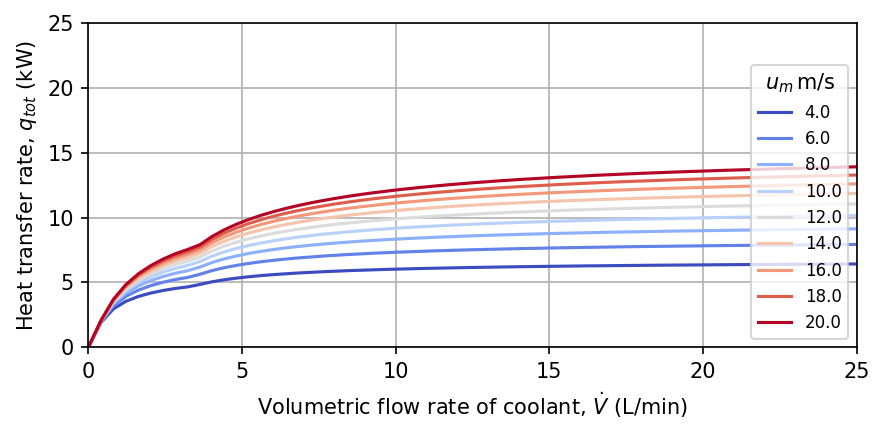

In [71]:
vdot_plot = np.linspace(0.01e-3/60, 80e-3/60, 200)
u_m_range = np.linspace(4, 20, 9)

fig, ax = plt.subplots(figsize=(6, 3), dpi=150)
ax.set_prop_cycle(plt.cycler("color", plt.cm.coolwarm(np.linspace(0, 1, len(u_m_range)))))
for u in u_m_range:
    r = solve_radiator(GEOMETRY, dict(CONDITIONS, u_m_air=u), vdot_plot, dual_pass=DUAL_PASS)
    ax.plot(vdot_plot*60*1e3, r['q']*1e-3, label=f"{u:1.1f}")
ax.set_xlim(0, 25)
ax.set_ylim(0, 25)
ax.set_xlabel(r'Volumetric flow rate of coolant, $\dot{V}$ (L/min)')
ax.set_ylabel(r'Heat transfer rate, $q_{tot}$ (kW)')
ax.legend(fontsize=8, title=r'$u_{m}\,\mathrm{m/s}$', loc=4)
ax.grid(True)
plt.tight_layout()
plt.show()


## Run — expected heat comparison, shift point FOS, gear pull maps

Uses `EXPECTED_HEAT` dict from Config cell.

Shift point evaluation (each case at its own speed + fan):
Case             RPM  Speed(mph)  u_air(m/s)  Flow(L/min)    Qdot(W)  Expected(W)    FOS
----------------------------------------------------------------------------------------
1st gear       10909       31.60      14.985        25.50    12253.5       7458.1   1.64
2nd gear       10789       41.85      19.365        25.28    13733.6       7455.1   1.84
3rd gear       10589       53.48      24.425        24.91    16653.5       7448.8   2.24
4th gear       10229       64.86      29.423        24.25    19812.4       7347.2   2.70
5th gear        9833       74.29      33.585        23.53    22081.5       7139.2   3.09
Max RPM        11000       74.29      33.585        25.67    22390.1       7458.1   3.00


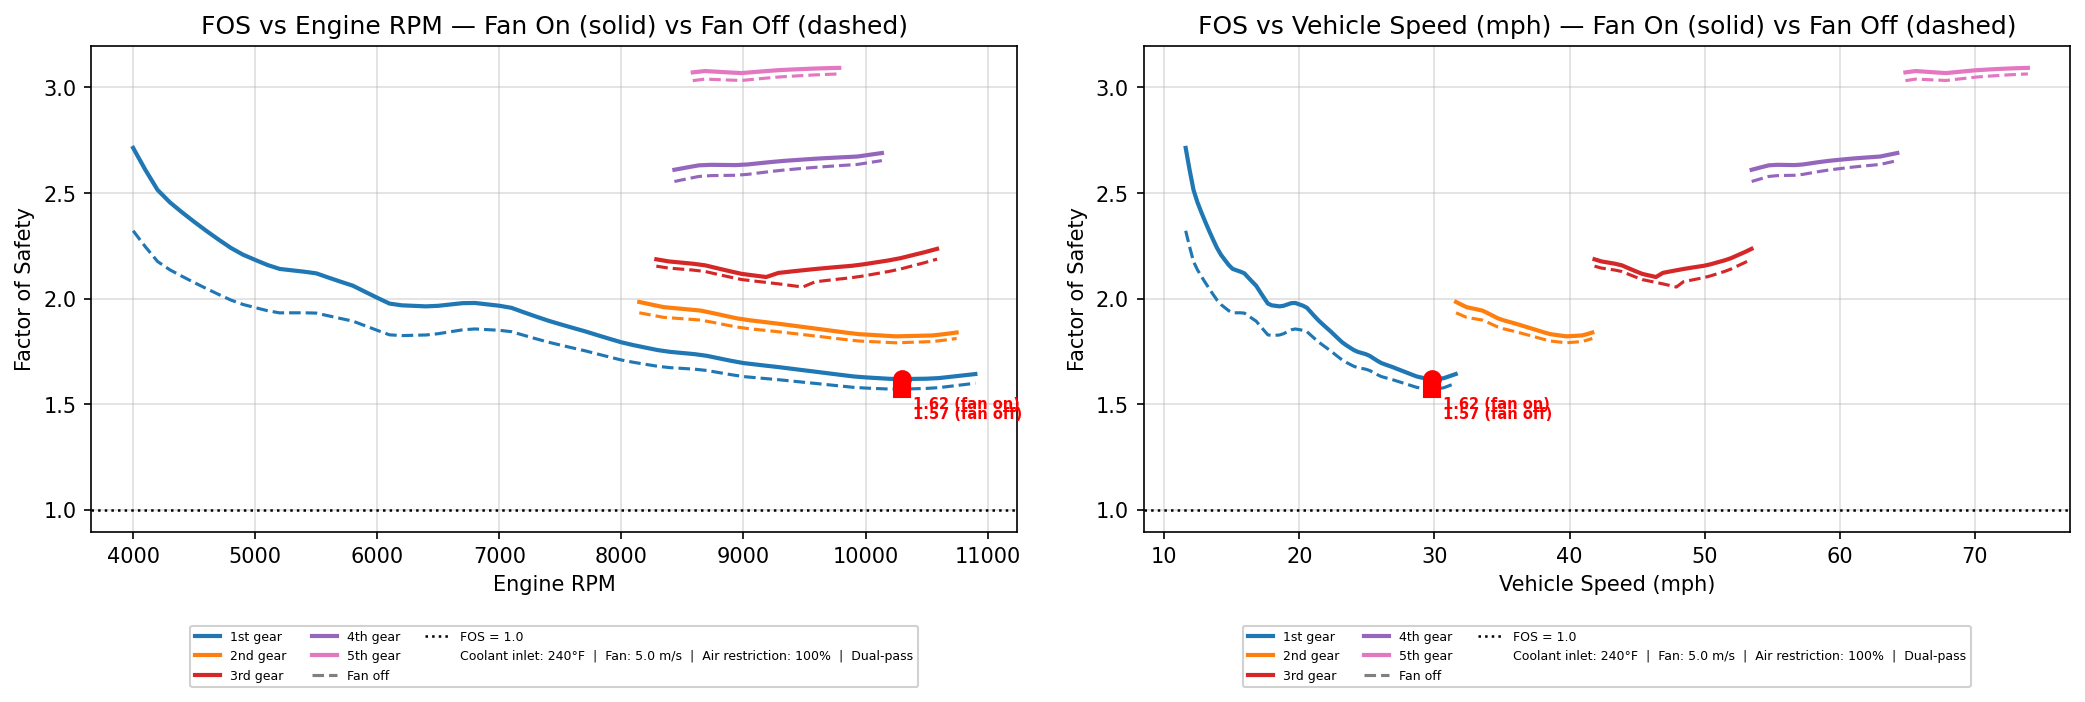

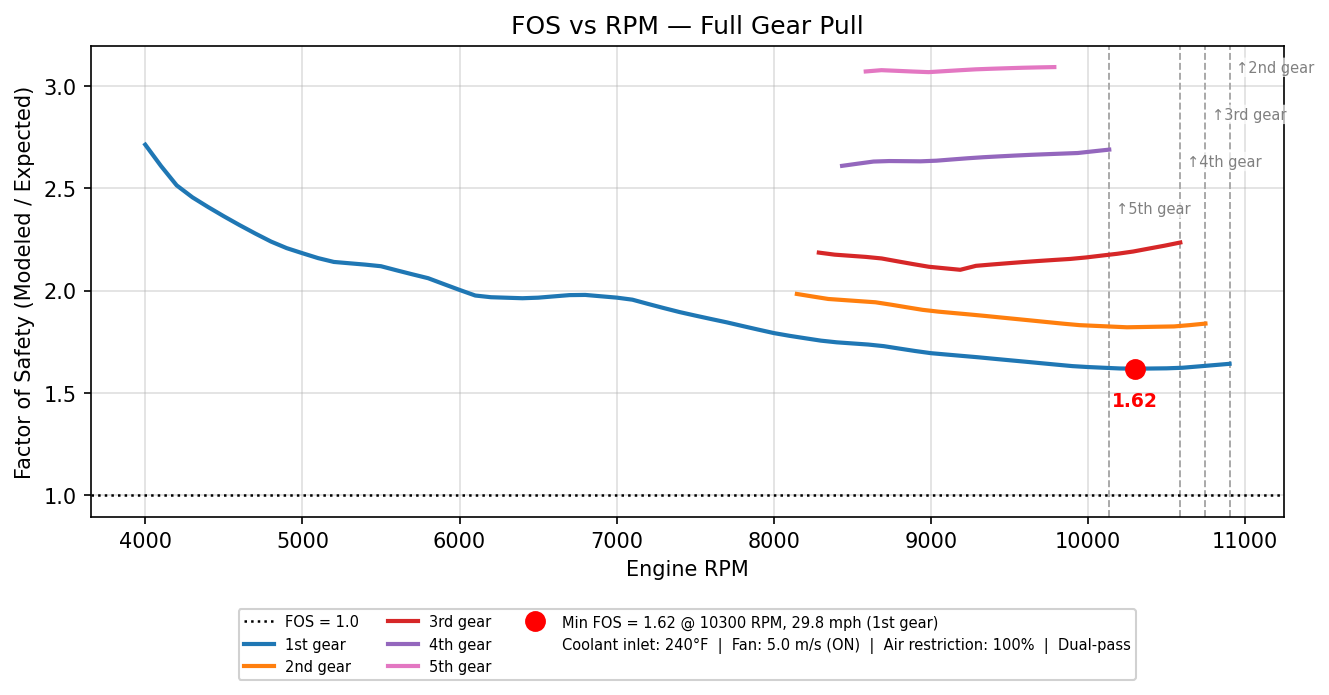

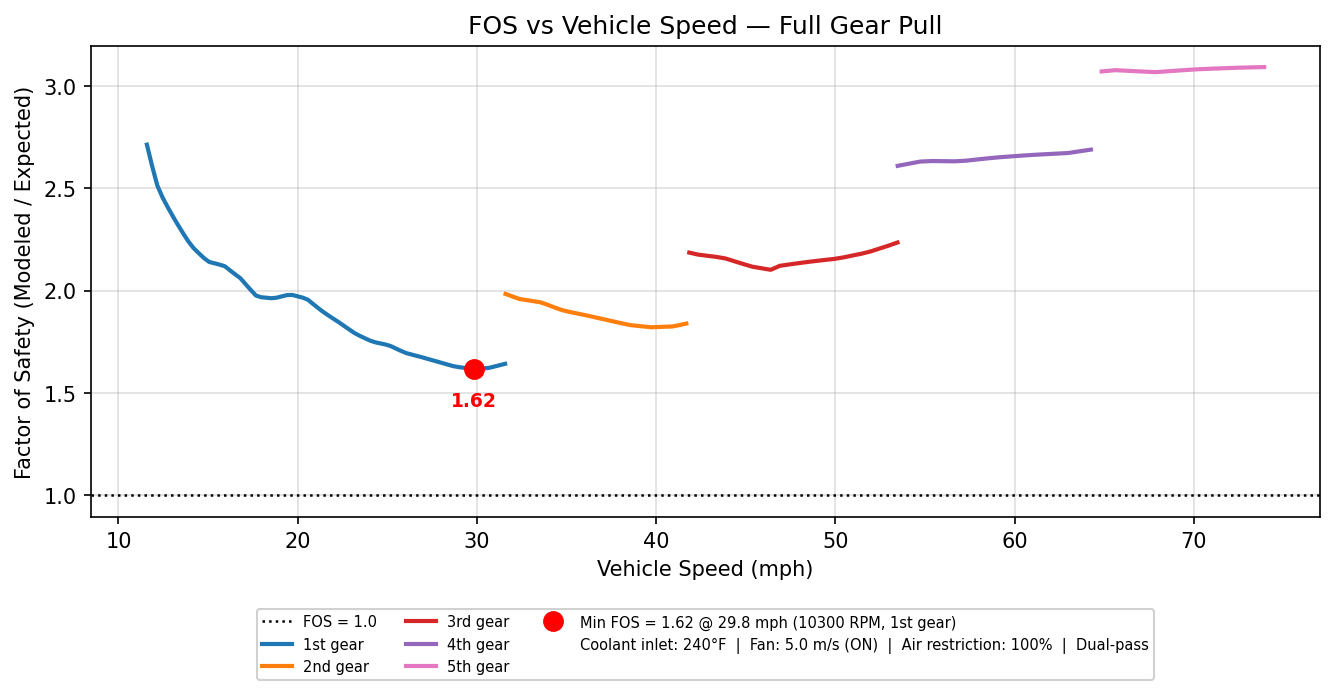

In [72]:
if EXPECTED_HEAT:
    # Build expected heat DataFrame directly from the config dict
    expected_df = pd.DataFrame({
        'RPM': list(EXPECTED_HEAT.keys()),
        'Expected_Heat_W': list(EXPECTED_HEAT.values()),
    }).sort_values('RPM').reset_index(drop=True)

    print("Shift point evaluation (each case at its own speed + fan):")
    print_shift_point_table(
        eval_shift_points(SHIFT_POINTS, AIR_RESTRICTION, GEOMETRY, CONDITIONS),
        expected_df=expected_df,
    )

    gear_map_on  = build_gear_fos_map(SHIFT_POINTS, AIR_RESTRICTION, GEOMETRY, CONDITIONS,
                                       expected_df=expected_df, rpm_step=100, launch_rpm=LAUNCH_RPM,
                                       fan_speed_ms=FAN_SPEED_MS, fan_on=True)
    gear_map_off = build_gear_fos_map(SHIFT_POINTS, AIR_RESTRICTION, GEOMETRY, CONDITIONS,
                                       expected_df=expected_df, rpm_step=100, launch_rpm=LAUNCH_RPM,
                                       fan_speed_ms=FAN_SPEED_MS, fan_on=False)

    gears  = gear_map_on['gear'].unique()
    colors = plt.cm.tab10(np.linspace(0, 0.6, len(gears)))

    fan_str   = f'{FAN_SPEED_MS:.1f} m/s'
    cond_label = (f'Coolant inlet: {T_WATER_F}°F  |  '
                  f'Fan: {fan_str}  |  '
                  f'Air restriction: {int(AIR_RESTRICTION*100)}%  |  '
                  f'{"Dual-pass" if DUAL_PASS else "Single-pass"}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)
    for ax, x_col, xlabel in zip(axes, ['rpm', 'mph'], ['Engine RPM', 'Vehicle Speed (mph)']):
        ax.axhline(1.0, color='k', linestyle=':', linewidth=1.2, zorder=2)
        for gear, color in zip(gears, colors):
            gon  = gear_map_on [gear_map_on ['gear']==gear]
            goff = gear_map_off[gear_map_off['gear']==gear]
            # solid = fan on (labeled), dashed = fan off (unlabeled — shown via legend note)
            ax.plot(gon [x_col], gon ['FOS'], '-',  color=color, linewidth=2,   label=gear)
            ax.plot(goff[x_col], goff['FOS'], '--', color=color, linewidth=1.5)
        for gmap, style, tag in [(gear_map_on,'o','fan on'),(gear_map_off,'s','fan off')]:
            mi = gmap['FOS'].idxmin(); mr = gmap.loc[mi]
            ax.plot(mr[x_col], mr['FOS'], style, color='red', markersize=8, zorder=5)
            ax.annotate(f"{mr['FOS']:.2f} ({tag})", xy=(mr[x_col], mr['FOS']),
                        xytext=(5,-14), textcoords='offset points', fontsize=7,
                        fontweight='bold', color='red')
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Factor of Safety')
        ax.set_title(f'FOS vs {xlabel} — Fan On (solid) vs Fan Off (dashed)')
        ax.grid(True, alpha=0.4)
        # Legend: gear colors (solid lines only) + FOS=1.0 + dashed note + conditions
        from matplotlib.lines import Line2D
        handles, labels = ax.get_legend_handles_labels()
        handles += [
            Line2D([0],[0], color='gray', linestyle='--', linewidth=1.5, label='Fan off'),
            Line2D([0],[0], color='k',    linestyle=':',  linewidth=1.2, label='FOS = 1.0'),
            Line2D([],[], color='none', label=cond_label),
        ]
        labels += ['Fan off', 'FOS = 1.0', cond_label]
        ax.legend(handles=handles, labels=labels,
                  fontsize=6, loc='upper center', bbox_to_anchor=(0.5,-0.18),
                  ncol=3, framealpha=0.9)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.28)
    plt.show()

    gear_map = gear_map_on if FAN_ON else gear_map_off

    # Build conditions label from current config values
    fan_str = f'{FAN_SPEED_MS:.1f} m/s ({"ON" if FAN_ON else "OFF"})'
    cond_label = (f'Coolant inlet: {T_WATER_F}°F  |  '
                  f'Fan: {fan_str}  |  '
                  f'Air restriction: {int(AIR_RESTRICTION*100)}%  |  '
                  f'{"Dual-pass" if DUAL_PASS else "Single-pass"}')

    plot_gear_fos_map(gear_map, shift_points=SHIFT_POINTS, conditions_label=cond_label)
    plt.show()
    plot_gear_fos_vs_speed(gear_map, conditions_label=cond_label)
    plt.show()

else:
    print("EXPECTED_HEAT is empty — add RPM: heat_W entries in the Config cell.")
